<a href="https://colab.research.google.com/github/mdreduanulhoque/AI_ML_Expert_with_Phitron/blob/main/Machine_Learning/Machine_Learning_Mid_Term.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [40]:
## Name: MD Reduanul Hoque
## Email: mdreduanulhoquesadik@gmail.com

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import SGDRegressor

Data Cleaning

In [42]:
df = pd.read_csv("adult_income.csv")
df

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,39,Private,215419,Bachelors,13,Divorced,Prof-specialty,Not-in-family,White,Female,0,0,36,United-States,<=50K.
48838,64,?,321403,HS-grad,9,Widowed,?,Other-relative,Black,Male,0,0,40,United-States,<=50K.
48839,38,Private,374983,Bachelors,13,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,50,United-States,<=50K.
48840,44,Private,83891,Bachelors,13,Divorced,Adm-clerical,Own-child,Asian-Pac-Islander,Male,5455,0,40,United-States,<=50K.


In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             48842 non-null  int64 
 1   workclass       48842 non-null  object
 2   fnlwgt          48842 non-null  int64 
 3   education       48842 non-null  object
 4   education-num   48842 non-null  int64 
 5   marital-status  48842 non-null  object
 6   occupation      48842 non-null  object
 7   relationship    48842 non-null  object
 8   race            48842 non-null  object
 9   sex             48842 non-null  object
 10  capital-gain    48842 non-null  int64 
 11  capital-loss    48842 non-null  int64 
 12  hours-per-week  48842 non-null  int64 
 13  native-country  48842 non-null  object
 14  income          48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB


In [44]:
df.describe()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,48842.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.643585,1.896641e+05,10.078089,1079.067626,87.502314,40.422382
std,13.710510,1.056040e+05,2.570973,7452.019058,403.004552,12.391444
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000


In [45]:
df.isnull().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,0
relationship,0
race,0
sex,0


In [46]:
for col in df.columns:
    print(f"{col}: {df[col].unique()} \n")

age: [39 50 38 53 28 37 49 52 31 42 30 23 32 40 34 25 43 54 35 59 56 19 20 45
 22 48 21 24 57 44 41 29 18 47 46 36 79 27 67 33 76 17 55 61 70 64 71 68
 66 51 58 26 60 90 75 65 77 62 63 80 72 74 69 73 81 78 88 82 83 84 85 86
 87 89] 

workclass: [' State-gov' ' Self-emp-not-inc' ' Private' ' Federal-gov' ' Local-gov'
 ' ?' ' Self-emp-inc' ' Without-pay' ' Never-worked'] 

fnlwgt: [ 77516  83311 215646 ... 173449  89686 350977] 

education: [' Bachelors' ' HS-grad' ' 11th' ' Masters' ' 9th' ' Some-college'
 ' Assoc-acdm' ' Assoc-voc' ' 7th-8th' ' Doctorate' ' Prof-school'
 ' 5th-6th' ' 10th' ' 1st-4th' ' Preschool' ' 12th'] 

education-num: [13  9  7 14  5 10 12 11  4 16 15  3  6  2  1  8] 

marital-status: [' Never-married' ' Married-civ-spouse' ' Divorced'
 ' Married-spouse-absent' ' Separated' ' Married-AF-spouse' ' Widowed'] 

occupation: [' Adm-clerical' ' Exec-managerial' ' Handlers-cleaners' ' Prof-specialty'
 ' Other-service' ' Sales' ' Craft-repair' ' Transport-moving'
 ' Farmin

In [47]:
df["income"] = df["income"].map({' <=50K': 0, ' >50K': 1, ' <=50K.': 0, ' >50K.': 1})

In [48]:
for col in df:
  print(f"{col} : {(df[col] == " ?").sum()}")

age : 0
workclass : 2799
fnlwgt : 0
education : 0
education-num : 0
marital-status : 0
occupation : 2809
relationship : 0
race : 0
sex : 0
capital-gain : 0
capital-loss : 0
hours-per-week : 0
native-country : 857
income : 0


In [49]:
miss_col = ["workclass", "occupation", "native-country"]
df[miss_col] = df[miss_col].replace(" ?", np.nan)

imputer = SimpleImputer( strategy="most_frequent")

df[miss_col] = imputer.fit_transform(df[miss_col])

In [50]:
for col in df:
  print(f"{col} : {(df[col] == " ?").sum()}")

age : 0
workclass : 0
fnlwgt : 0
education : 0
education-num : 0
marital-status : 0
occupation : 0
relationship : 0
race : 0
sex : 0
capital-gain : 0
capital-loss : 0
hours-per-week : 0
native-country : 0
income : 0


In [51]:
bins_ = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
df["age_group"] = pd.cut(df["age"], bins= bins_)

Question 1

<Axes: xlabel='age_group', ylabel='income'>

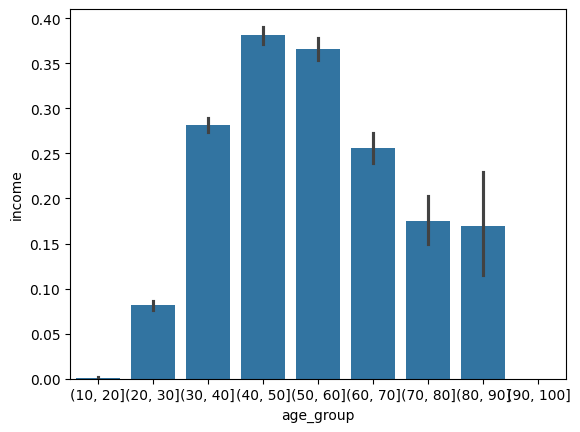

In [52]:
sns.barplot(df, x= "age_group", y = "income")

<Axes: xlabel='education', ylabel='income'>

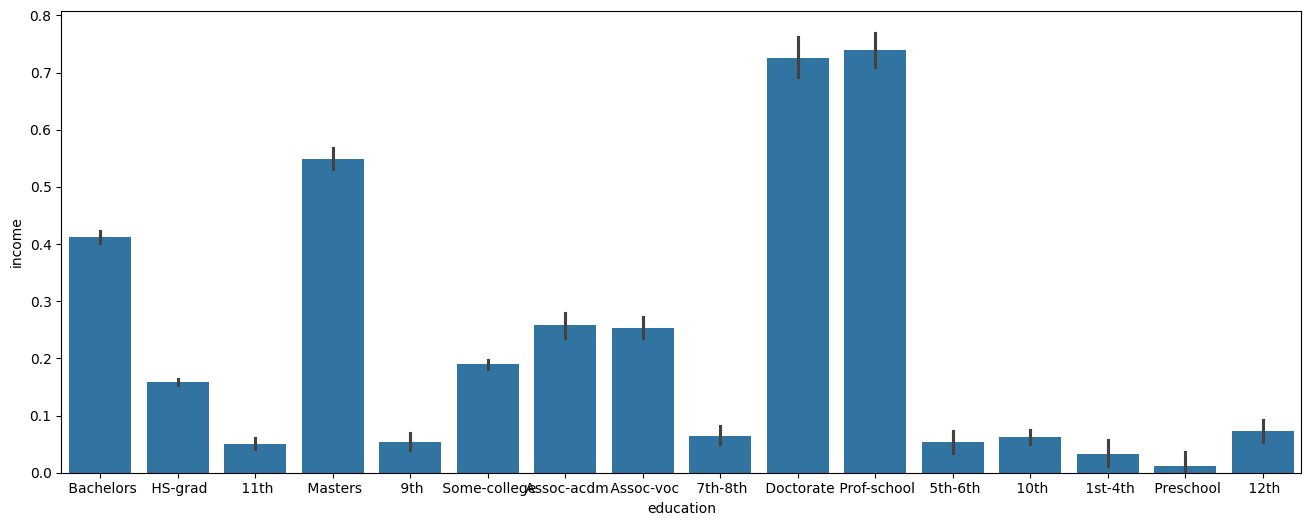

In [53]:
plt.figure(figsize=(16,6))
sns.barplot(df, x= "education", y= "income", )

<Axes: xlabel='hours_bin', ylabel='count'>

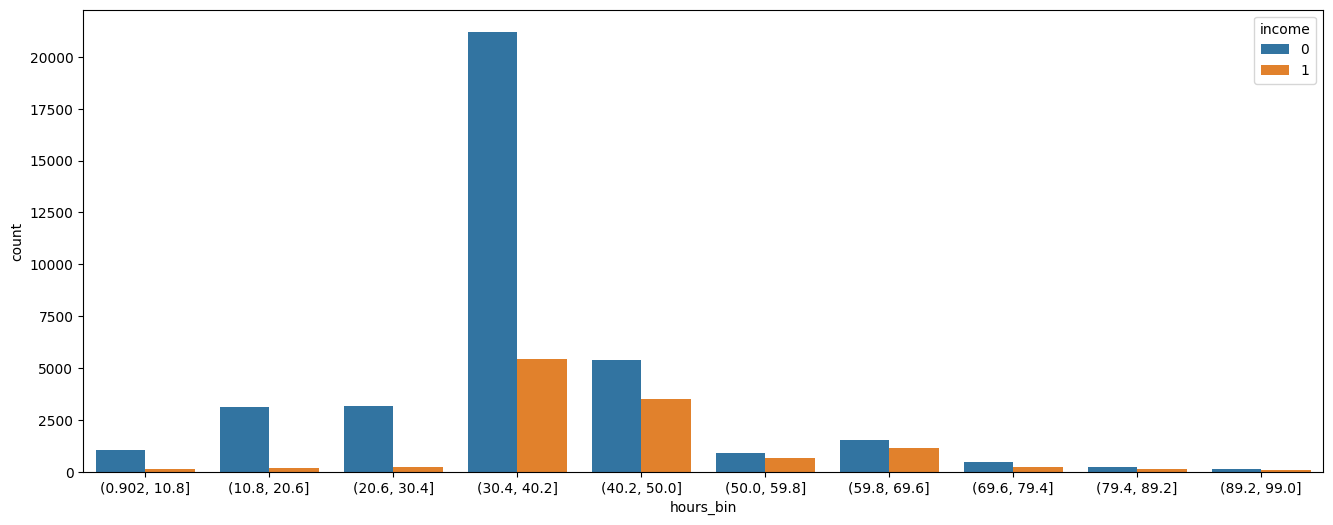

In [54]:
plt.figure(figsize=(16,6))
df["hours_bin"] = pd.cut(df["hours-per-week"], bins=10)
sns.countplot(x="hours_bin", hue="income", data=df)

<Axes: xlabel='marital-status', ylabel='income'>

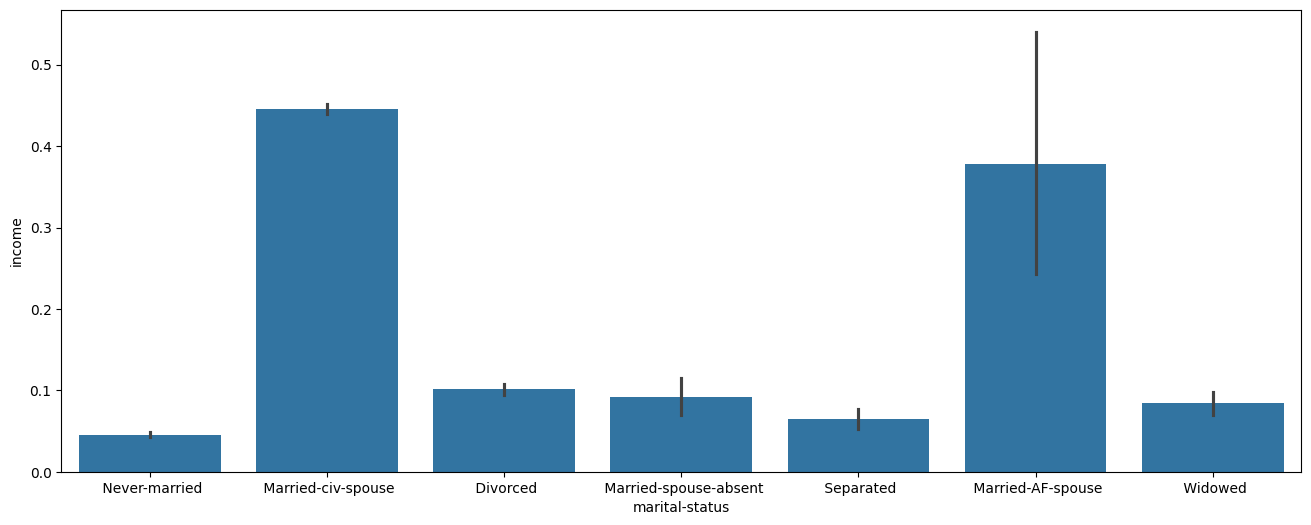

In [55]:
plt.figure(figsize=(16,6))
sns.barplot(df, x= "marital-status", y= "income", )

<Axes: xlabel='workclass', ylabel='income'>

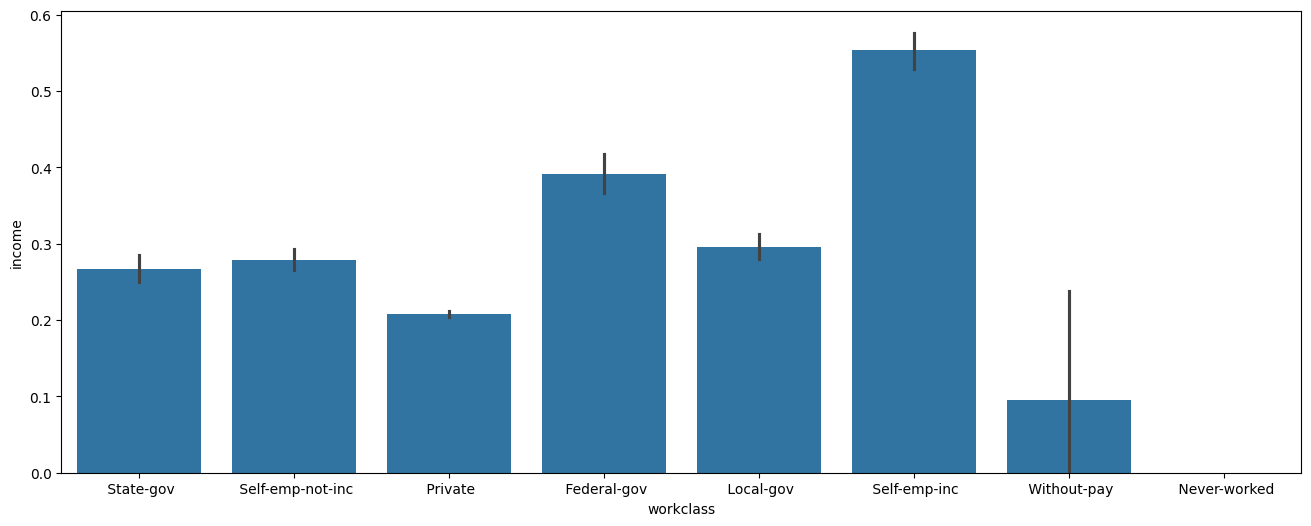

In [56]:
plt.figure(figsize=(16,6))
sns.barplot(df, x= "workclass", y= "income", )

<Axes: xlabel='relationship', ylabel='income'>

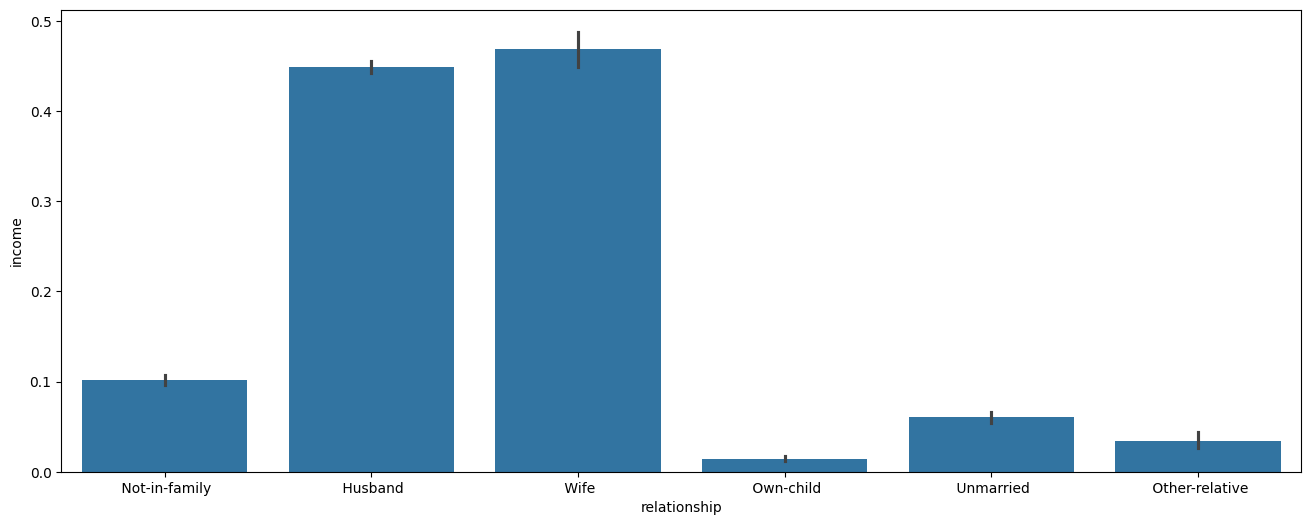

In [57]:
plt.figure(figsize=(16,6))
sns.barplot(df, x= "relationship", y= "income")

<Axes: xlabel='native-country', ylabel='income'>

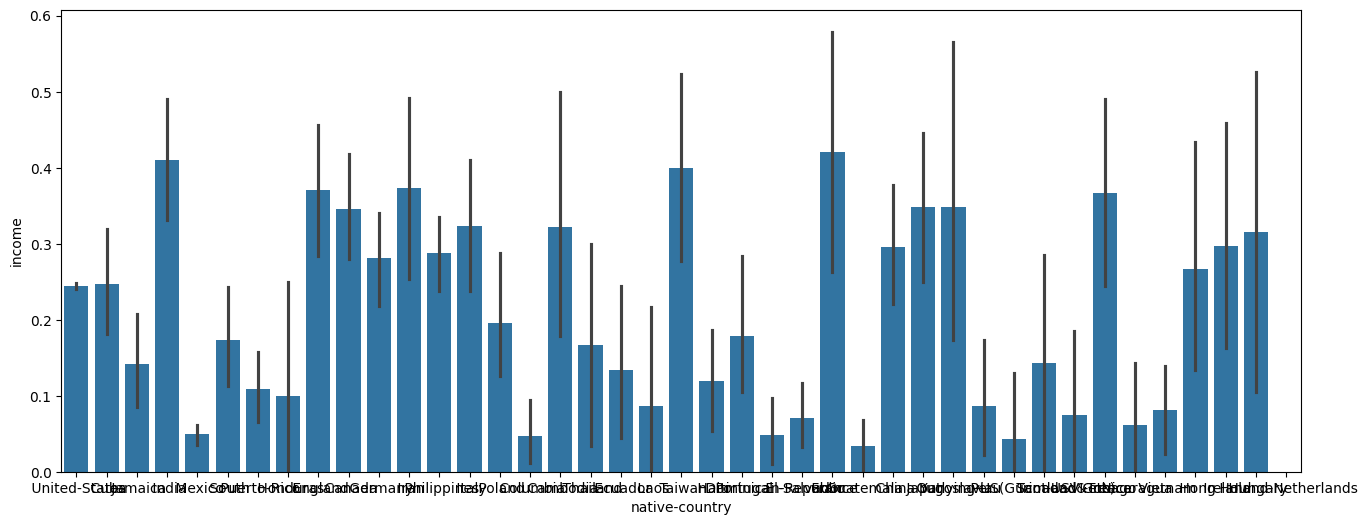

In [58]:
plt.figure(figsize=(16,6))
sns.barplot(df, x= "native-country", y= "income", )

<Axes: xlabel='occupation', ylabel='income'>

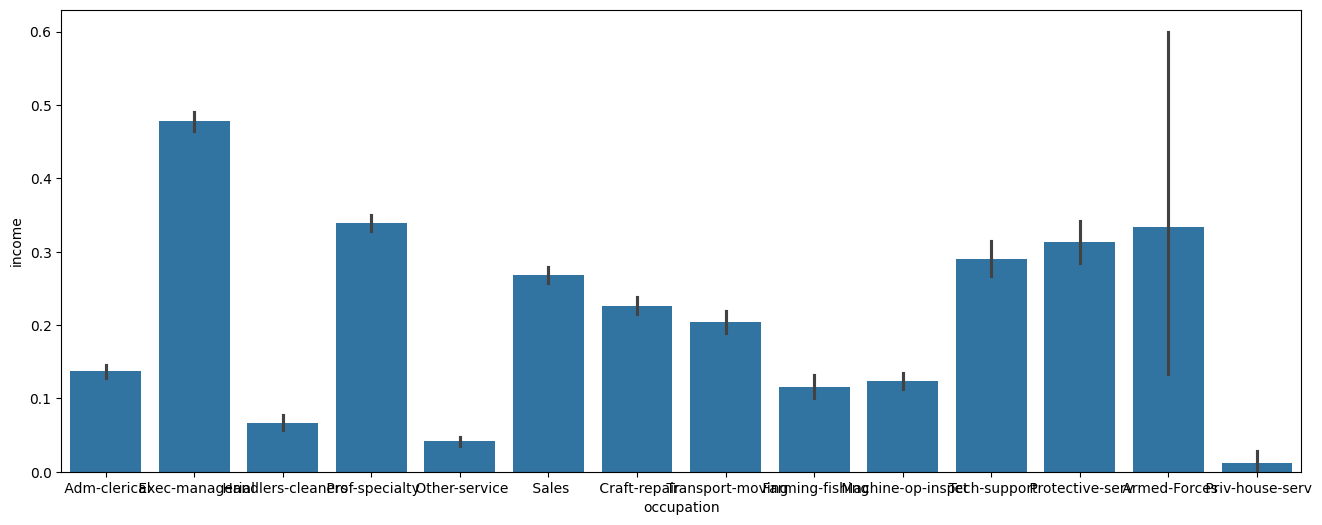

In [59]:
plt.figure(figsize=(16,6))
sns.barplot(df, x= "occupation", y= "income", )

<Axes: xlabel='race', ylabel='income'>

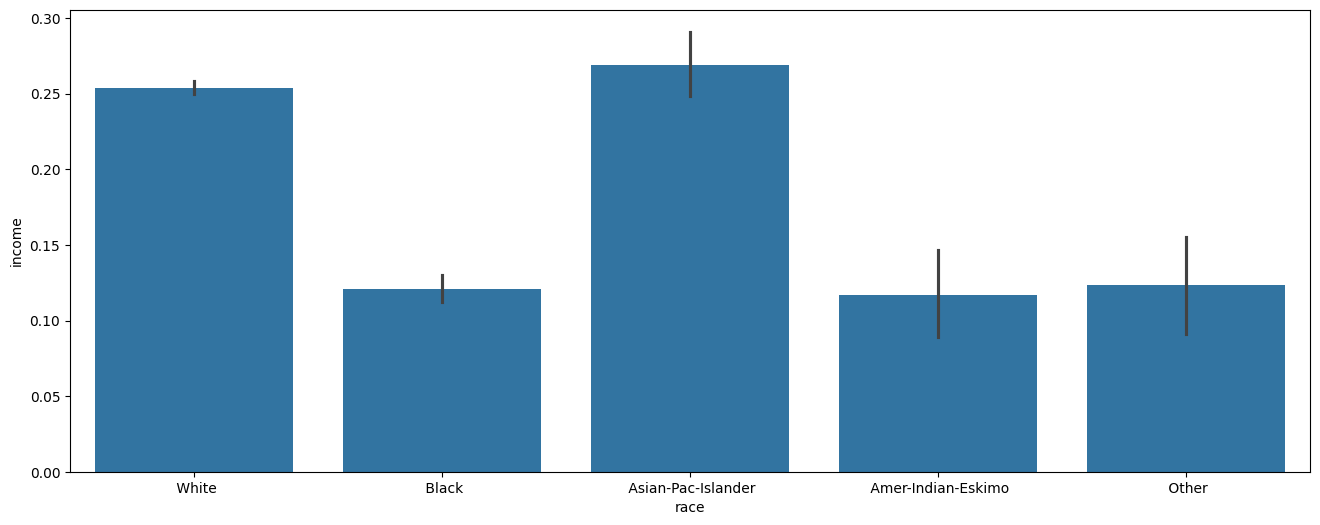

In [60]:
plt.figure(figsize=(16,6))
sns.barplot(df, x= "race", y= "income", )

<Axes: >

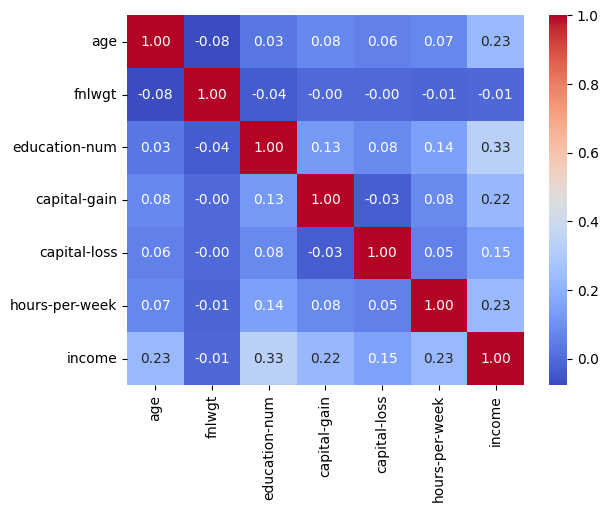

In [61]:
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")

In [62]:
'''

My ranking:
1. education : Directly impacts on thinking process, decission making ability, occupation and earning.
2. age / age_group : Impacts on physical and mental health, pressure taking ability and attraction for money.
3. hours-per-week : Related to effort making and income directly

'''

'\n\nMy ranking:\n1. education : Directly impacts on thinking process, decission making ability, occupation and earning.\n2. age / age_group : Impacts on physical and mental health, pressure taking ability and attraction for money.\n3. hours-per-week : Related to effort making and income directly\n\n'

Question 2

In [63]:
df.columns

Index(['age', 'workclass', 'fnlwgt', 'education', 'education-num',
       'marital-status', 'occupation', 'relationship', 'race', 'sex',
       'capital-gain', 'capital-loss', 'hours-per-week', 'native-country',
       'income', 'age_group', 'hours_bin'],
      dtype='object')

In [64]:
df.drop(columns=["age_group", "hours_bin"])

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,0
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,0
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,0
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,0
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,39,Private,215419,Bachelors,13,Divorced,Prof-specialty,Not-in-family,White,Female,0,0,36,United-States,0
48838,64,Private,321403,HS-grad,9,Widowed,Prof-specialty,Other-relative,Black,Male,0,0,40,United-States,0
48839,38,Private,374983,Bachelors,13,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,50,United-States,0
48840,44,Private,83891,Bachelors,13,Divorced,Adm-clerical,Own-child,Asian-Pac-Islander,Male,5455,0,40,United-States,0


In [65]:
## Feature-Target Split
X = df.drop(columns=["hours-per-week"], axis=1)
y = df["hours-per-week"]

## Extracting numerical and categorical Column
num_feature = X.select_dtypes(include=["number"]).columns
cat_feature = X.select_dtypes(include=["object", "category"]).columns

## num_transformer with SimpleImputer and strategy "median",
## Scaling with StandardScaler
num_transformer = Pipeline(
    steps = [
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

## cat_transformer with SimpleImputer and strategy "most_frequent",
## Encoding with OneHotENcoder
cat_transformer = Pipeline(
    steps = [
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

## Main preprocessor using column transformer
preprocessor = ColumnTransformer(
    transformers= [
        ("num", num_transformer, num_feature),
        ("cat", cat_transformer, cat_feature)
    ]
)

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 Index(['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss',
       'income'],
      dtype='object')),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 Index(['workclass', 'education', 'marital-status', 'occupation',
       'relationship', 'race', 'sex', 'native-country', 'age_group',
       'hours_bin'],
      dtype='object'))])